Dataset Shape: (569, 30)

First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst 

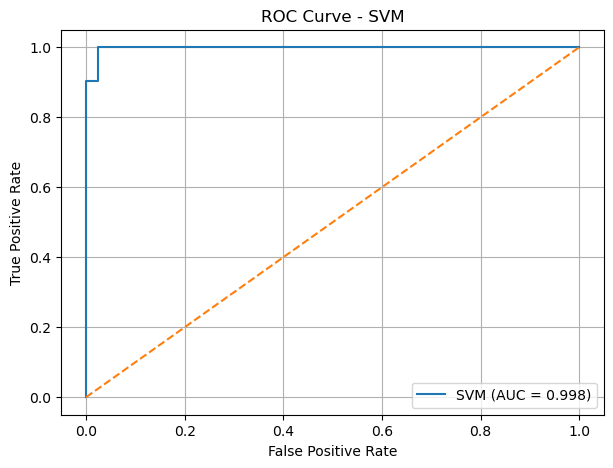



EXPERIMENT 4B - RANDOM FOREST

Best Random Forest Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

----- RANDOM FOREST RESULTS -----
Accuracy : 0.9561
Precision: 0.9589
Recall   : 0.9722
F1-Score : 0.9655
ROC-AUC  : 0.9937

Confusion Matrix:
[[39  3]
 [ 2 70]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



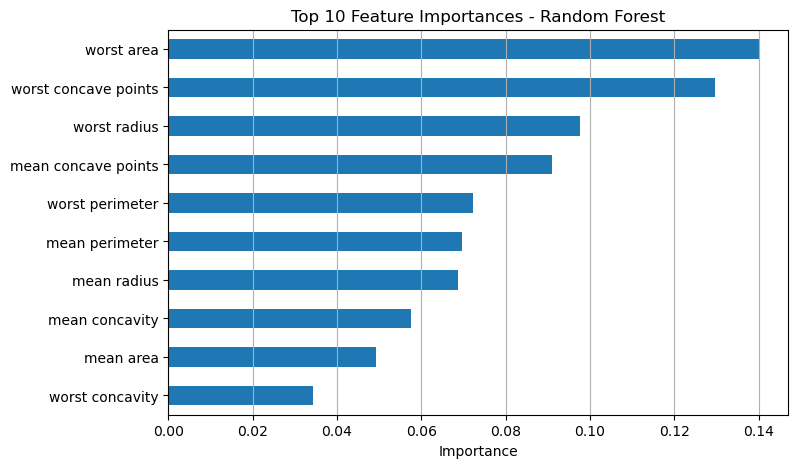

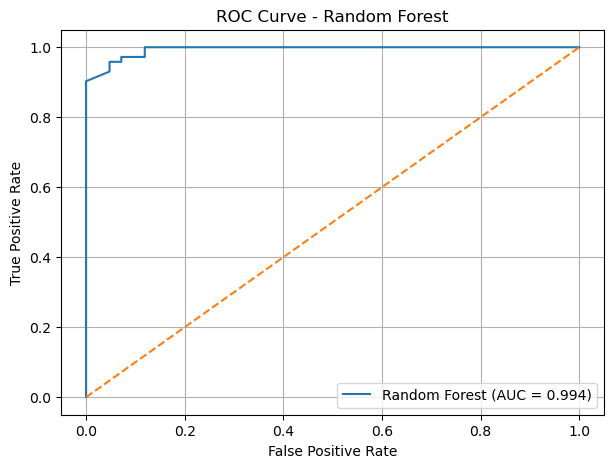



SVM vs RANDOM FOREST
           Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0            SVM    0.9825     0.9861  0.9861    0.9861   0.9977
1  Random Forest    0.9561     0.9589  0.9722    0.9655   0.9937

===== EXPERIMENT 4A & 4B COMPLETED =====


In [1]:
# ============================================================
# EXPERIMENT 4A + 4B
# SVM AND RANDOM FOREST CLASSIFICATION
# ============================================================

# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)


# ============================================================
# LOAD DATASET
# ============================================================

data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    data.target,
    name="target"
)

print("Dataset Shape:", X.shape)

print("\nFirst 5 rows:")
print(X.head())


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


# ============================================================
#                  EXPERIMENT 4A
#                  SUPPORT VECTOR MACHINE
# ============================================================

print("\n")
print("=" * 60)
print("EXPERIMENT 4A - SUPPORT VECTOR MACHINE")
print("=" * 60)


# -----------------------------
# STANDARDIZATION
# -----------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# -----------------------------
# CREATE SVM MODEL
# -----------------------------

svm = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)


# -----------------------------
# HYPERPARAMETER GRID
# -----------------------------

svm_param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.001, 0.0001]
}


# -----------------------------
# GRID SEARCH
# -----------------------------

svm_grid = GridSearchCV(
    estimator=svm,
    param_grid=svm_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

svm_grid.fit(X_train_scaled, y_train)


# -----------------------------
# BEST PARAMETERS
# -----------------------------

print("\nBest SVM Parameters:")
print(svm_grid.best_params_)


# -----------------------------
# BEST SVM MODEL
# -----------------------------

best_svm = svm_grid.best_estimator_

y_pred_svm = best_svm.predict(X_test_scaled)

y_prob_svm = best_svm.predict_proba(X_test_scaled)[:, 1]


# -----------------------------
# SVM EVALUATION
# -----------------------------

svm_accuracy = accuracy_score(y_test, y_pred_svm)

svm_precision = precision_score(
    y_test,
    y_pred_svm,
    zero_division=0
)

svm_recall = recall_score(
    y_test,
    y_pred_svm
)

svm_f1 = f1_score(
    y_test,
    y_pred_svm
)

svm_auc = roc_auc_score(
    y_test,
    y_prob_svm
)

svm_cm = confusion_matrix(
    y_test,
    y_pred_svm
)


print("\n----- SVM RESULTS -----")

print("Accuracy :", round(svm_accuracy, 4))
print("Precision:", round(svm_precision, 4))
print("Recall   :", round(svm_recall, 4))
print("F1-Score :", round(svm_f1, 4))
print("ROC-AUC  :", round(svm_auc, 4))

print("\nConfusion Matrix:")
print(svm_cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_svm,
        zero_division=0
    )
)


# -----------------------------
# SVM ROC CURVE
# -----------------------------

fpr_svm, tpr_svm, _ = roc_curve(
    y_test,
    y_prob_svm
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_svm,
    tpr_svm,
    label=f"SVM (AUC = {svm_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
#                  EXPERIMENT 4B
#                  RANDOM FOREST
# ============================================================

print("\n")
print("=" * 60)
print("EXPERIMENT 4B - RANDOM FOREST")
print("=" * 60)


# -----------------------------
# CREATE RANDOM FOREST MODEL
# -----------------------------

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)


# -----------------------------
# HYPERPARAMETER GRID
# -----------------------------

rf_param_grid = {
    "n_estimators": [100],
    "max_depth": [None, 10],
    "min_samples_split": [2],
    "min_samples_leaf": [1]
}


# -----------------------------
# GRID SEARCH
# -----------------------------

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1
)

# Random Forest does NOT require scaling
rf_grid.fit(X_train, y_train)


# -----------------------------
# BEST PARAMETERS
# -----------------------------

print("\nBest Random Forest Parameters:")
print(rf_grid.best_params_)


# -----------------------------
# BEST RANDOM FOREST MODEL
# -----------------------------

best_rf = rf_grid.best_estimator_

y_pred_rf = best_rf.predict(X_test)

y_prob_rf = best_rf.predict_proba(X_test)[:, 1]


# -----------------------------
# RANDOM FOREST EVALUATION
# -----------------------------

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    y_pred_rf
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf
)

rf_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

rf_cm = confusion_matrix(
    y_test,
    y_pred_rf
)


print("\n----- RANDOM FOREST RESULTS -----")

print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1-Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_auc, 4))

print("\nConfusion Matrix:")
print(rf_cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf,
        zero_division=0
    )
)


# ============================================================
# RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

importances = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
)

top10 = importances.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(8, 5))

top10.sort_values().plot(
    kind="barh"
)

plt.xlabel("Importance")
plt.title("Top 10 Feature Importances - Random Forest")
plt.grid(axis="x")

plt.show()


# ============================================================
# RANDOM FOREST ROC CURVE
# ============================================================

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# FINAL COMPARISON
# ============================================================

print("\n")
print("=" * 60)
print("SVM vs RANDOM FOREST")
print("=" * 60)

comparison = pd.DataFrame({
    "Model": ["SVM", "Random Forest"],
    "Accuracy": [svm_accuracy, rf_accuracy],
    "Precision": [svm_precision, rf_precision],
    "Recall": [svm_recall, rf_recall],
    "F1-Score": [svm_f1, rf_f1],
    "ROC-AUC": [svm_auc, rf_auc]
})

print(comparison.round(4))


print("\n===== EXPERIMENT 4A & 4B COMPLETED =====")